# 02 - EDA of Synthetic AML Data

## Goal

This notebook checks raw-data quality, distributions, scenario coverage, and sanctions variations. It does not build features or models.

## 1. Load generated CSV data

Run notebook 01 first. This cell stops with a clear message if any required CSV is missing.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "notebooks").exists():
    ROOT = ROOT.parent
RAW_DIR, TRUTH_DIR = ROOT / "data" / "raw", ROOT / "data" / "ground_truth"
required = [RAW_DIR / name for name in ["customers.csv", "accounts.csv", "transactions.csv", "counterparties.csv", "sanctions_watchlist.csv"]] + [TRUTH_DIR / name for name in ["aml_ground_truth.csv", "sanctions_ground_truth.csv"]]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Run 01_generate_synthetic_data.ipynb first. Missing: " + ", ".join(missing))

customers = pd.read_csv(RAW_DIR / "customers.csv")
accounts = pd.read_csv(RAW_DIR / "accounts.csv")
transactions = pd.read_csv(RAW_DIR / "transactions.csv", parse_dates=["transaction_timestamp"])
counterparties = pd.read_csv(RAW_DIR / "counterparties.csv")
watchlist = pd.read_csv(RAW_DIR / "sanctions_watchlist.csv")
aml_truth = pd.read_csv(TRUTH_DIR / "aml_ground_truth.csv")
sanctions_truth = pd.read_csv(TRUTH_DIR / "sanctions_ground_truth.csv")
pd.set_option("display.max_columns", 30)


In [2]:
print(customers.head(3))

  customer_id      full_name first_name     middle_name last_name  \
0  CUS0000001  Andi Iskandar       Andi  NO_MIDDLE_NAME  Iskandar   
1  CUS0000002  Putri Gunawan      Putri              R.   Gunawan   
2  CUS0000003  Laras Nugraha      Laras  NO_MIDDLE_NAME   Nugraha   

  date_of_birth  gender nationality id_type        id_number  \
0    1958-08-31  Female  Indonesian     KTP  SYN699988764001   
1    1973-05-04  Female  Indonesian     KTP  SYN028183613122   
2    1989-08-11  Female  Indonesian     KTP  SYN659110310704   

        address_line_1 address_line_2      city          province  \
0  Jl. Adinata No. 129         Blok B   Jakarta       DKI Jakarta   
1   Jl. Budiman No. 61        Unit 12  Makassar  Sulawesi Selatan   
2  Jl. Chandra No. 168        Unit 12   Bandung        Jawa Barat   

   postal_code country  phone_number                                 email  \
0        32248      ID  628258191279  customer0000001@synthetic.vteki.test   
1        57052      ID  628155197

In [3]:
print(accounts.head(3))

    account_id customer_id  account_number account_type currency branch_code  \
0  ACC00000001  CUS0005100   8806376456622       Saving      USD      BR0061   
1  ACC00000002  CUS0003882   8875523347304       Saving      IDR      BR0289   
2  ACC00000003  CUS0001498   8808524846169       Saving      IDR      BR0049   

  opening_date account_status  average_balance risk_level  current_balance  
0   2022-06-17         Active       7078882.78     Medium       5138302.34  
1   2022-02-12         Active      37956572.17        Low      40237438.53  
2   2020-02-20         Active       7111171.06        Low      11676340.43  


In [4]:
print(transactions.head(10))


  transaction_id transaction_timestamp sender_customer_id sender_account_id  \
0  TXN0000000001   2025-11-03 00:00:18         CUS0004481       ACC00003723   
1  TXN0000000002   2025-11-03 00:02:26         CUS0007453       ACC00007015   
2  TXN0000000003   2025-11-03 00:03:18         CUS0005894       ACC00000669   
3  TXN0000000004   2025-11-03 00:04:15         CUS0000187       ACC00014403   
4  TXN0000000005   2025-11-03 00:06:48         CUS0004923       ACC00010305   
5  TXN0000000006   2025-11-03 00:09:02         CUS0009012       ACC00007934   
6  TXN0000000007   2025-11-03 00:11:11         CUS0007860       ACC00014939   
7  TXN0000000008   2025-11-03 00:14:25         CUS0005278       ACC00006675   
8  TXN0000000009   2025-11-03 00:15:28         CUS0008434       ACC00005517   
9  TXN0000000010   2025-11-03 00:16:47         CUS0008497       ACC00002250   

        sender_name        sender_address sender_country  \
0       Hana Wibowo  Jl. Rahardjo No. 213             ID   
1      Ran

In [5]:
print(transactions["receiver_customer_id"].value_counts().head(10))


receiver_customer_id
EXTERNAL_NOT_BANK_CUSTOMER    180007
CUS0009994                        32
CUS0004767                        30
CUS0009228                        29
CUS0003433                        29
CUS0000451                        28
CUS0006682                        28
CUS0002475                        27
CUS0008323                        27
CUS0002041                        27
Name: count, dtype: int64


In [6]:
transactions["transaction_timestamp"].describe()

count                        250000
mean     2026-03-03 02:00:11.440636
min             2025-11-03 00:00:18
25%      2026-01-02 03:45:44.750000
50%      2026-03-03 01:07:03.500000
75%             2026-05-01 23:52:53
max             2026-06-30 23:59:53
Name: transaction_timestamp, dtype: object

In [7]:
print(counterparties.tail(20))

     counterparty_id      counterparty_name entity_type       alias_name  \
4980       CP0004981    PT Wibowo Synthetic     Company      Maya Wibowo   
4981       CP0004982            Kevin Putra  Individual      Kevin Putra   
4982       CP0004983   PT Nugraha Synthetic     Company    Intan Nugraha   
4983       CP0004984         Laras Mahendra  Individual   Laras Mahendra   
4984       CP0004985           Sari Gunawan  Individual     Sari Gunawan   
4985       CP0004986   PT Budiman Synthetic     Company    Farah Budiman   
4986       CP0004987           Adit Santoso  Individual     Adit Santoso   
4987       CP0004988  PT Rahardjo Synthetic     Company    Alya Rahardjo   
4988       CP0004989           Sari Adinata  Individual     Sari Adinata   
4989       CP0004990   PT Permana Synthetic     Company    Wulan Permana   
4990       CP0004991         Putri Iskandar  Individual   Putri Iskandar   
4991       CP0004992        Nadia Kurniawan  Individual  Nadia Kurniawan   
4992       C

In [8]:
print(watchlist.head(3))

  watchlist_id entity_type    primary_name first_name     middle_name  \
0     WL000001  Individual    Farid Petrov      Farid  NO_MIDDLE_NAME   
1     WL000002  Individual     Ivan Volkov       Ivan  NO_MIDDLE_NAME   
2     WL000003  Individual  Hassan Karimov     Hassan  NO_MIDDLE_NAME   

  last_name         aliases date_of_birth    place_of_birth nationality  \
0    Petrov    Farid Petrov    1978-04-12  Synthetic City A          RU   
1    Volkov     Ivan Volkov    1978-04-12  Synthetic City B          SY   
2   Karimov  Hassan Karimov    1978-04-12           Unknown          KP   

                address              city country passport_number  \
0   52 Watchlist Street  Synthetic City B      RU  SYN-P-91731754   
1  179 Watchlist Street  Synthetic City B      SY  SYN-P-41147766   
2  229 Watchlist Street  Synthetic City A      RU  SYN-P-67601804   

       national_id          organization_name             program  \
0  SYN-N-633756577  NOT_APPLICABLE_INDIVIDUAL  Synthetic Reg

In [9]:
print(watchlist["organization_name"].value_counts())

organization_name
NOT_APPLICABLE_INDIVIDUAL    944
Petrov Global Holdings        41
Karimov Global Holdings       38
Abramov Global Holdings       38
Ivanov Global Holdings        31
Volkov Global Holdings        30
Haddad Global Holdings        29
Sokolov Global Holdings       28
Bashir Global Holdings        21
Name: count, dtype: int64


In [21]:
print(aml_truth.tail(5))

    transaction_id customer_id scenario_id           scenario_name  \
995  TXN0000095486  CUS0000787     AML-S10  Potential Mule Account   
996  TXN0000049873  CUS0003826     AML-S10  Potential Mule Account   
997  TXN0000014324  CUS0001578     AML-S10  Potential Mule Account   
998  TXN0000237304  CUS0007619     AML-S10  Potential Mule Account   
999  TXN0000044863  CUS0005845     AML-S10  Potential Mule Account   

     injected_flag expected_risk  \
995              1      Critical   
996              1      Critical   
997              1      Critical   
998              1      Critical   
999              1      Critical   

                                               notes scenario_group_id  
995  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0024  
996  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025  
997  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025  
998  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025

In [11]:
print(aml_truth.tail(3))

    transaction_id customer_id scenario_id           scenario_name  \
997  TXN0000014324  CUS0001578     AML-S10  Potential Mule Account   
998  TXN0000237304  CUS0007619     AML-S10  Potential Mule Account   
999  TXN0000044863  CUS0005845     AML-S10  Potential Mule Account   

     injected_flag expected_risk  \
997              1      Critical   
998              1      Critical   
999              1      Critical   

                                               notes scenario_group_id  
997  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025  
998  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025  
999  Synthetic injection for Potential Mule Account.  AML-S10-GRP-0025  


In [12]:
print(sanctions_truth.head(3))

  transaction_id watchlist_id    injected_name   original_name variation_type  \
0  TXN0000217118     WL000439        L. Ivanov    Laila Ivanov   Abbreviation   
1  TXN0000110816     WL000324     Karix Volkov    Karim Volkov           Typo   
2  TXN0000234443     WL000140  Sergei  Abramov  Sergei Abramov        Spacing   

   expected_match  
0               1  
1               1  
2               1  


In [13]:
print(sanctions_truth.tail(3))

    transaction_id watchlist_id            injected_name  \
747  TXN0000131310     WL000139              Omax Bashir   
748  TXN0000161379     WL000325  Karimox Global Holdings   
749  TXN0000135325     WL000953   Volkox Global Holdings   

               original_name variation_type  expected_match  
747              Omar Bashir           Typo               1  
748  Karimov Global Holdings           Typo               1  
749   Volkov Global Holdings           Typo               1  


## 3. Table volume and primary-key checks

Each dataset should have the required grain and unique main identifier.

In [14]:
tables = {"customers": (customers, "customer_id"), "accounts": (accounts, "account_id"), "transactions": (transactions, "transaction_id"), "counterparties": (counterparties, "counterparty_id"), "watchlist": (watchlist, "watchlist_id")}
summary = pd.DataFrame([{"table": name, "rows": len(frame), "columns": frame.shape[1], "duplicate_keys": int(frame[key].duplicated().sum())} for name, (frame, key) in tables.items()])
display(summary)
assert (summary["duplicate_keys"] == 0).all()

,table,rows,columns,duplicate_keys
0,customers,10000,26,0
1,accounts,15000,11,0
2,transactions,250000,32,0
3,counterparties,5000,16,0
4,watchlist,1200,23,0


## 4. Customer and account profile distributions

All monetary charts below use **Rp juta** so the scale is immediately readable. `Capped at P99` means the chart only limits its *display* to the 99th percentile (the top 1% is not shown in the chart); no data is removed from the CSV files.

,metric,unit,median,p95,p99 (batas tampilan grafik)
0,Monthly income,Rp juta per bulan,12.11,40.11,67.04
1,Average account balance,Rp juta,14.88,87.14,182.70


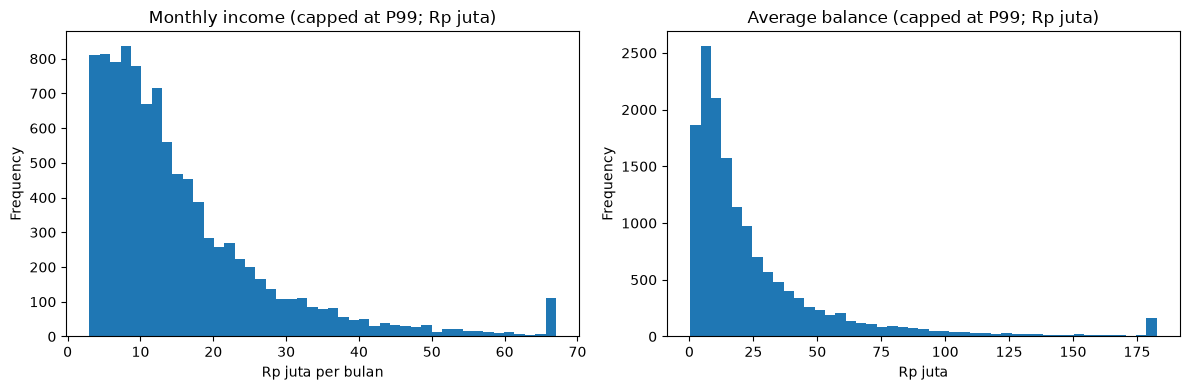

In [15]:
RUPIAH_PER_MILLION = 1_000_000

profile_amount_summary = pd.DataFrame(
    {
        "metric": ["Monthly income", "Average account balance"],
        "unit": ["Rp juta per bulan", "Rp juta"],
        "median": [customers["monthly_income"].median() / RUPIAH_PER_MILLION,
                   accounts["average_balance"].median() / RUPIAH_PER_MILLION],
        "p95": [customers["monthly_income"].quantile(0.95) / RUPIAH_PER_MILLION,
                accounts["average_balance"].quantile(0.95) / RUPIAH_PER_MILLION],
        "p99 (batas tampilan grafik)": [customers["monthly_income"].quantile(0.99) / RUPIAH_PER_MILLION,
                                         accounts["average_balance"].quantile(0.99) / RUPIAH_PER_MILLION],
    }
).round(2)
display(profile_amount_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
income_p99 = customers["monthly_income"].quantile(0.99)
income_in_millions = customers["monthly_income"].clip(upper=income_p99) / RUPIAH_PER_MILLION
income_in_millions.plot.hist(bins=45, ax=axes[0])
axes[0].set_title("Monthly income (capped at P99; Rp juta)")
axes[0].set_xlabel("Rp juta per bulan")
axes[0].set_ylabel("Frequency")

balance_p99 = accounts["average_balance"].quantile(0.99)
balance_in_millions = accounts["average_balance"].clip(upper=balance_p99) / RUPIAH_PER_MILLION
balance_in_millions.plot.hist(bins=45, ax=axes[1])
axes[1].set_title("Average balance (capped at P99; Rp juta)")
axes[1].set_xlabel("Rp juta")
axes[1].set_ylabel("Frequency")
plt.tight_layout()

## 5. Transaction baseline

Review transaction type, status, date range, and amount distribution before interpreting any injected scenario. `amount_idr_equivalent` is the value of **one transaction**, converted into rupiah. The amount chart uses **Rp juta per transaction**; its P99 cap affects only the displayed chart.

,value
first_transaction,2025-11-03 00:00:18
last_transaction,2026-06-30 23:59:53
success_rate,0.0
international_transactions,93244


,transactions
transaction_type,
BI-FAST,87246
Transfer,85403
Cash,29942
SWIFT,24848
RTGS,22561


,metric,unit,median,p95,p99 (batas tampilan grafik)
0,Individual transaction amount,Rp juta per transaksi,2.82,19.03,44.22


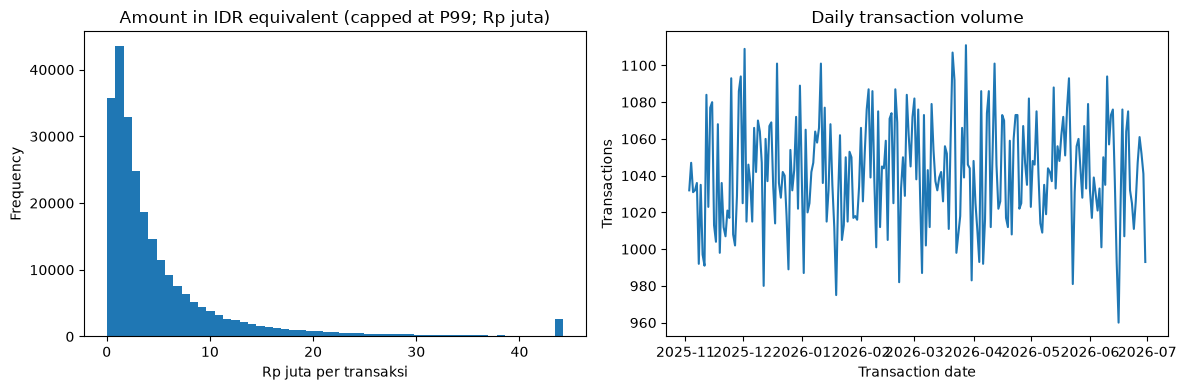

In [16]:
display(
    pd.Series(
        {
            "first_transaction": transactions["transaction_timestamp"].min(),
            "last_transaction": transactions["transaction_timestamp"].max(),
            "success_rate": (transactions["transaction_status"] == "SUCCESS").mean(),
            "international_transactions": int(transactions["sender_country"].ne(transactions["receiver_country"]).sum()),
        }
    ).to_frame("value")
)
display(transactions["transaction_type"].value_counts().to_frame("transactions"))

transaction_amount_summary = pd.DataFrame(
    {
        "metric": ["Individual transaction amount"],
        "unit": ["Rp juta per transaksi"],
        "median": [transactions["amount_idr_equivalent"].median() / RUPIAH_PER_MILLION],
        "p95": [transactions["amount_idr_equivalent"].quantile(0.95) / RUPIAH_PER_MILLION],
        "p99 (batas tampilan grafik)": [transactions["amount_idr_equivalent"].quantile(0.99) / RUPIAH_PER_MILLION],
    }
).round(2)
display(transaction_amount_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
transaction_p99 = transactions["amount_idr_equivalent"].quantile(0.99)
transaction_amount_in_millions = transactions["amount_idr_equivalent"].clip(upper=transaction_p99) / RUPIAH_PER_MILLION
transaction_amount_in_millions.plot.hist(bins=55, ax=axes[0])
axes[0].set_title("Amount in IDR equivalent (capped at P99; Rp juta)")
axes[0].set_xlabel("Rp juta per transaksi")
axes[0].set_ylabel("Frequency")
transactions["transaction_timestamp"].dt.date.value_counts().sort_index().plot(ax=axes[1])
axes[1].set_title("Daily transaction volume")
axes[1].set_xlabel("Transaction date")
axes[1].set_ylabel("Transactions")
plt.tight_layout()

## 6. AML ground-truth coverage

All ten mandatory assignment scenarios must exist and point to actual transaction IDs.

In [17]:
scenario_summary = aml_truth.groupby(["scenario_id", "scenario_name", "expected_risk"], as_index=False).agg(labelled_transactions=("transaction_id", "nunique"), customers=("customer_id", "nunique")).sort_values("scenario_id")
display(scenario_summary)
assert scenario_summary["scenario_id"].nunique() == 10
assert aml_truth["transaction_id"].isin(transactions["transaction_id"]).all()

,scenario_id,scenario_name,expected_risk,labelled_transactions,customers
0,AML-S01,Structuring / Smurfing,High,100,100
1,AML-S02,Sudden Transaction Spike,High,100,99
2,AML-S03,Rapid Movement of Funds,Critical,100,99
3,AML-S04,Dormant Account Reactivation,Critical,100,100
4,AML-S05,Multiple Senders to One Receiver,High,100,100
5,AML-S06,One Sender to Multiple Beneficiaries,High,100,100
6,AML-S07,Circular Transaction,Critical,100,99
7,AML-S08,High-Risk Geography,High,100,100
8,AML-S09,Unusual Transaction Purpose,High,100,99
9,AML-S10,Potential Mule Account,Critical,100,99


## 7. Sanctions-watchlist and variation coverage

The screening dataset includes exact names and deliberate variants for future name-matching evaluation.

In [18]:
display(watchlist["entity_type"].value_counts().to_frame("watchlist_records"))
variation_summary = sanctions_truth.groupby(["variation_type", "expected_match"], as_index=False).agg(cases=("transaction_id", "nunique")).sort_values("variation_type")
display(variation_summary)
assert sanctions_truth["transaction_id"].isin(transactions["transaction_id"]).all()

,watchlist_records
entity_type,
Individual,944
Organization,256


,variation_type,expected_match,cases
0,Abbreviation,1,130
1,Alias,1,125
2,Exact,1,118
3,Reversed,1,113
4,Spacing,1,116
5,Typo,1,148


## 8. Referential integrity

The final raw-data check confirms master-table relationships and positive transaction amounts.

In [19]:
checks = pd.Series({"accounts_resolve_to_customers": accounts["customer_id"].isin(customers["customer_id"]).all(), "transaction_senders_resolve_to_customers": transactions["sender_customer_id"].isin(customers["customer_id"]).all(), "positive_amounts": (transactions["amount_idr_equivalent"] > 0).all()})
display(checks.to_frame("passed"))
assert checks.all()

,passed
accounts_resolve_to_customers,True
transaction_senders_resolve_to_customers,True
positive_amounts,True


## Takeaway

The synthetic raw-data layer is ready. The next phase is Analytical Base Table construction, leakage-safe feature engineering, and configurable AML red flags.